In [31]:
import pandas as pd

data = pd.read_csv('preprocessed_data.csv')
print(data.shape) 

(76518, 38)


In [32]:
# Example: Drop 'id' and 'Target'
features = data.drop(['id', 'Target'], axis=1)

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features)

# Calculate and print explained variance
variance_explained = pca.explained_variance_ratio_.sum()
print(f"Total variance explained by 2 principal components: {variance_explained:.2%}")

# Optional: Individual component variances
print(f"Individual variances: PC1 = {pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2 = {pca.explained_variance_ratio_[1]:.2%}")

Total variance explained by 2 principal components: 35.58%
Individual variances: PC1 = 22.16%, PC2 = 13.41%


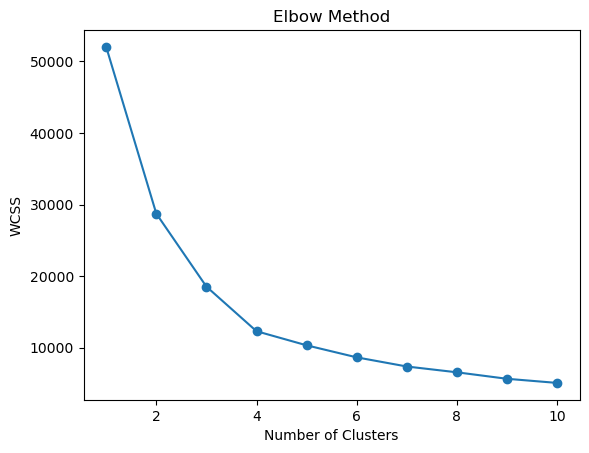

In [34]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(pca_result)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [35]:
# KMeans
kmeans = KMeans(n_clusters=3)
data['KMeans_Cluster'] = kmeans.fit_predict(pca_result)

# DBSCAN
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
data['DBSCAN_Cluster'] = dbscan.fit_predict(pca_result)
print(data['KMeans_Cluster'].value_counts())  # Step 5
print(data['DBSCAN_Cluster'].value_counts())  # Step 5

KMeans_Cluster
0    35683
1    22017
2    18818
Name: count, dtype: int64
DBSCAN_Cluster
0    76518
Name: count, dtype: int64


In [36]:
data.to_csv('data_with_clusters.csv', index=False)
print("File saved as data_with_clusters.csv")

File saved as data_with_clusters.csv


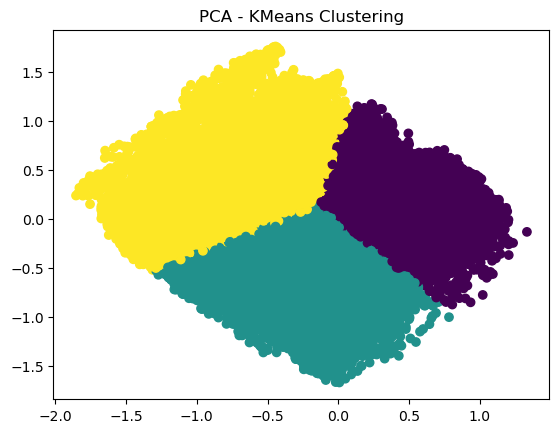

In [37]:
plt.scatter(pca_result[:,0], pca_result[:,1], c=data['KMeans_Cluster'])
plt.title('PCA - KMeans Clustering')
plt.show()